# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** [Enter Group Number]

**Student names & numbers:**
* [Name 1] - [Student no.]
* [Name 2] - [Student no.]
* [Name 3] - [Student no.]


---

## 0. Setup

**Import libraries**

In [39]:
# CODE CELL: import the necessary libraries for this iteration
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.4f}'.format)

**Load dataset(s)**

In [40]:
# CODE CELL: import the necessary dataset(s) for this iteration
df_observation = pd.read_csv("./data/Dicentrarchus labrax.csv", low_memory=False)
df_habitats = pd.read_csv("./data/habitats_cbs_2022.csv")

# df_weather = pd.read_csv("./data/weather.csv", comment='#')
df_water = pd.read_csv("./data/haringvliet_salinity_temp_daily_2010_2025.csv")

In [41]:
df_water[['salinity_mean']] = df_water[['salinity_mean']] / 1000
df_water.head()

,date,salinity_mean,temperature_mean
0,2010-01-01 00:00:00+00:00,NaN,NaN
1,2010-01-02 00:00:00+00:00,NaN,NaN
2,2010-01-03 00:00:00+00:00,NaN,NaN
3,2010-01-04 00:00:00+00:00,NaN,NaN
4,2010-01-05 00:00:00+00:00,NaN,NaN


In [42]:
df_observation.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Dicentrarchus labrax       str    
dtypes: float64(3), int64(1), str(2)
memory usage: 574.9 MB


In [43]:
df_observation['eventDate'] = pd.to_datetime(df_observation['eventDate'])

df_obs_habitat = pd.merge(
    df_observation, 
    df_habitats, 
    on=['decimalLatitude', 'decimalLongitude'], 
    how='left'
)


df_obs_habitat['eventDate'] = pd.to_datetime(df_obs_habitat['eventDate']).dt.tz_localize(None)
df_water['date'] = pd.to_datetime(df_water['date']).dt.tz_localize(None)


df_obs_habitat_water = df_obs_habitat.merge(
    df_water,
    left_on='eventDate',
    right_on='date',
    how='left'
)

df_obs_habitat_water.drop(columns=['date'], inplace=True)


df_obs_habitat_water['Dicentrarchus labrax'] = pd.to_numeric(df_obs_habitat_water['Dicentrarchus labrax'], errors='coerce')
df_obs_habitat_water.sample(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat,salinity_mean,temperature_mean
3564895,51.7500,5.5500,2010-02-25,0.0000,0,0.0000,9.0156,5.6351,0.0000,2.4167,1.6926,0.0951,0.1561,0.1792,agricultural,NaN,NaN
4973705,52.0000,5.0500,2011-04-07,25.0000,0,0.0000,3.2374,8.3814,0.0000,0.5409,5.2528,0.0011,1.6687,0.0051,built,31.6975,9.4906
9534326,52.8000,6.3000,2017-07-25,0.0000,0,0.0000,14.4927,1.0053,0.0000,2.0901,0.8864,0.0354,0.2413,0.0000,agricultural,31.7913,19.7924
3565407,51.7500,5.5500,2011-07-22,9.0000,0,0.0000,9.0156,5.6351,0.0000,2.4167,1.6926,0.0951,0.1561,0.1792,agricultural,NaN,NaN
6619824,52.2500,5.9500,2022-02-03,0.0000,0,0.0000,11.7841,4.4421,0.0000,0.5998,1.9045,0.0000,0.2295,0.0246,agricultural,27.0751,6.7903


In [44]:
# 1. Inspect missing values 
df_missing = df_obs_habitat_water[df_obs_habitat_water.isnull().any(axis=1)]
display(df_missing.head(5))

print("Missing value counts:")
print(df_obs_habitat_water.isnull().sum())

# 2. Drop rows where habitat info is missing (geographic join failure)
habitat_cols = ['agricultural', 'built', 'coast', 'forest', 'other',
                'sand/heather', 'water', 'wetland', 'main_habitat']

df_no_missing = df_obs_habitat_water.dropna(subset=habitat_cols)


# 3. Sort by date before interpolation
df_no_missing = df_no_missing.copy()
df_no_missing = df_no_missing.sort_values('eventDate').reset_index(drop=True)

# 4. Short gaps (≤14 days): linear interpolation
df_no_missing['salinity_mean'] = (
    df_no_missing['salinity_mean']
    .interpolate(method='linear', limit=14)
)
df_no_missing['temperature_mean'] = (
    df_no_missing['temperature_mean']
    .interpolate(method='linear', limit=14)
)

# 5. Longer gaps (>14 days): fill with historical seasonal mean
df_no_missing['doy'] = pd.to_datetime(df_no_missing['eventDate']).dt.dayofyear
seasonal_sal  = df_no_missing.groupby('doy')['salinity_mean'].transform('mean')
seasonal_temp = df_no_missing.groupby('doy')['temperature_mean'].transform('mean')

df_no_missing['salinity_mean']    = df_no_missing['salinity_mean'].fillna(seasonal_sal)
df_no_missing['temperature_mean'] = df_no_missing['temperature_mean'].fillna(seasonal_temp)

df_no_missing = df_no_missing.drop(columns='doy')

# 6. Verify 
print("\nRemaining missing values after processing:")
print(df_no_missing.isnull().sum())


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat,salinity_mean,temperature_mean
0,50.7500,5.6500,2010-01-01,0.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,NaN,NaN
1,50.7500,5.6500,2010-01-02,26.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,NaN,NaN
2,50.7500,5.6500,2010-01-03,3.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,NaN,NaN
3,50.7500,5.6500,2010-01-04,0.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,NaN,NaN
4,50.7500,5.6500,2010-01-05,0.0000,0,0.0000,1.7747,0.0568,0.0000,0.0616,0.0582,0.0000,0.4688,0.0000,agricultural,NaN,NaN


Missing value counts:
decimalLatitude                    0
decimalLongitude                   0
eventDate                          0
total_observations                 1
speciesgroup_observations          0
Dicentrarchus labrax               4
agricultural                      30
built                             30
coast                             30
forest                            30
other                             30
sand/heather                      30
water                             30
wetland                           30
main_habitat                      30
salinity_mean                2529403
temperature_mean             1151894
dtype: int64

Remaining missing values after processing:
decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           0
speciesgroup_observations    0
Dicentrarchus labrax         0
agricultural                 0
built                        0
coast                        0
forest       

In [45]:
# observations with effort but no fish
true_absent = df_no_missing[(df_no_missing['total_observations'] > 0) & (df_no_missing['Dicentrarchus labrax'] == 0)]
print(f"Number of true absent records: {len(true_absent)}")

# no observations at all
no_effort = df_no_missing[df_no_missing['total_observations'] == 0]
print(f"Number of no effort records: {len(no_effort)}")

# clean no effort records
df_clean = df_no_missing[df_no_missing['total_observations'] > 0]

Number of true absent records: 6537558
Number of no effort records: 6019157


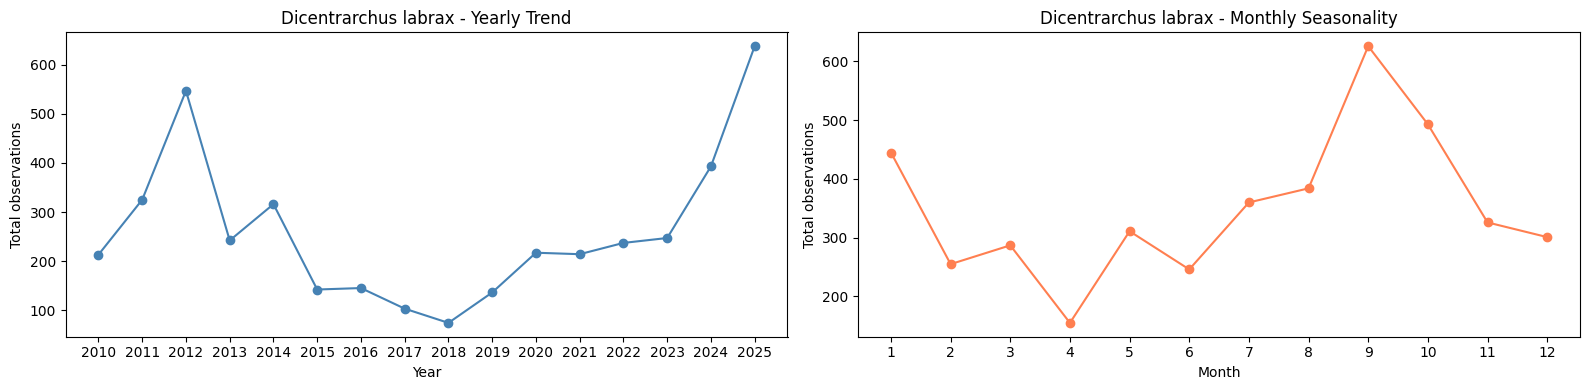

In [46]:
# fixes the SettingWithCopyWarning
df_visual = df_clean.copy()  

df_visual['eventDate'] = pd.to_datetime(df_visual['eventDate'])
df_visual['year'] = df_visual['eventDate'].dt.year
df_visual['month'] = df_visual['eventDate'].dt.month

present_mask = df_visual['Dicentrarchus labrax'] > 0
absent_mask  = df_visual['Dicentrarchus labrax'] == 0

#Year
yearly_species = (
    df_visual.groupby('year')['Dicentrarchus labrax']
    .sum()
    .sort_index()
)

# Month seasonality 
monthly_species = (
    df_visual.groupby('month')['Dicentrarchus labrax']
    .sum()
    .reindex(range(1, 13), fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# left
yearly_species.plot(
    ax=axes[0],
    marker='o',
    color='steelblue'
)

axes[0].set_title('Dicentrarchus labrax - Yearly Trend')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total observations')

# display all years on x-axis with rotation
axes[0].set_xticks(yearly_species.index)

# right
monthly_species.plot(
    ax=axes[1],
    marker='o',
    color='coral'
)

axes[1].set_title('Dicentrarchus labrax - Monthly Seasonality')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total observations')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

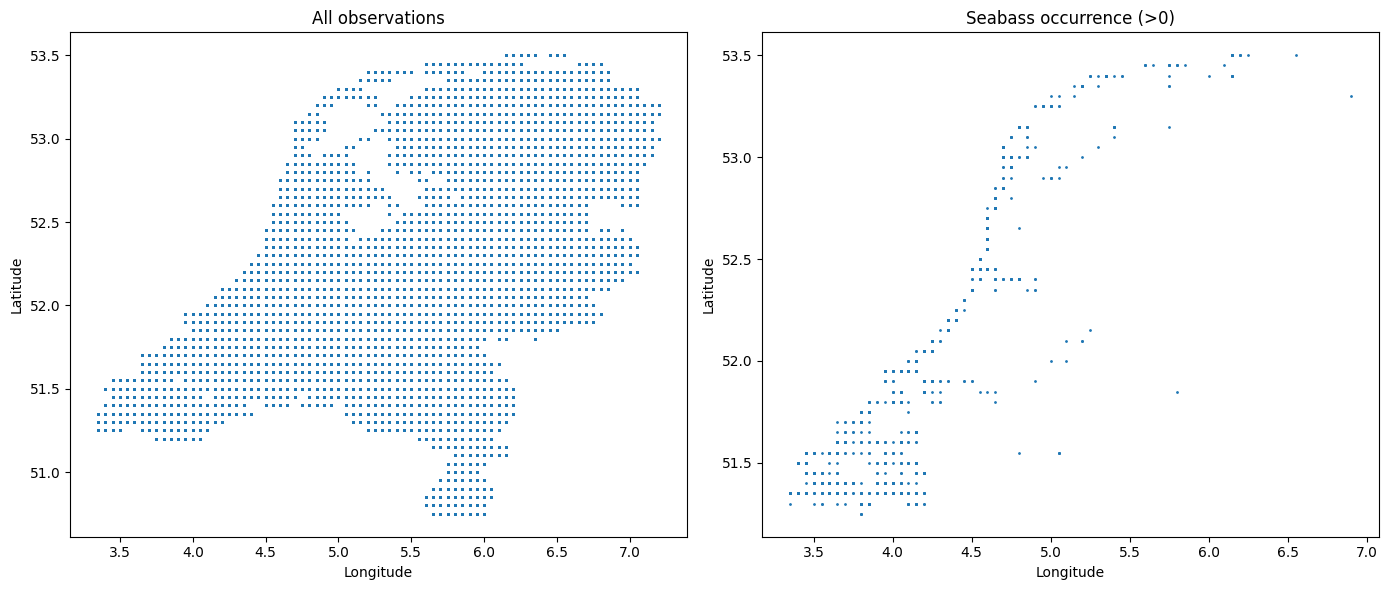

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left
axes[0].scatter(
    df_visual['decimalLongitude'],
    df_visual['decimalLatitude'],
    s=1
)
axes[0].set_title("All observations")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# right
df_seabass = df_visual[present_mask]

axes[1].scatter(
    df_seabass['decimalLongitude'],
    df_seabass['decimalLatitude'],
    s=1
)
axes[1].set_title("Seabass occurrence (>0)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

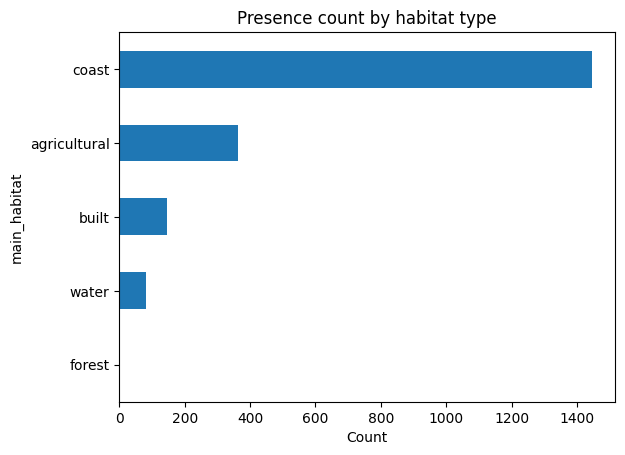

In [48]:
df_visual[present_mask].groupby('main_habitat')['Dicentrarchus labrax'].count().sort_values().plot(kind='barh')
plt.xlabel('Count')
plt.title('Presence count by habitat type')
plt.show()

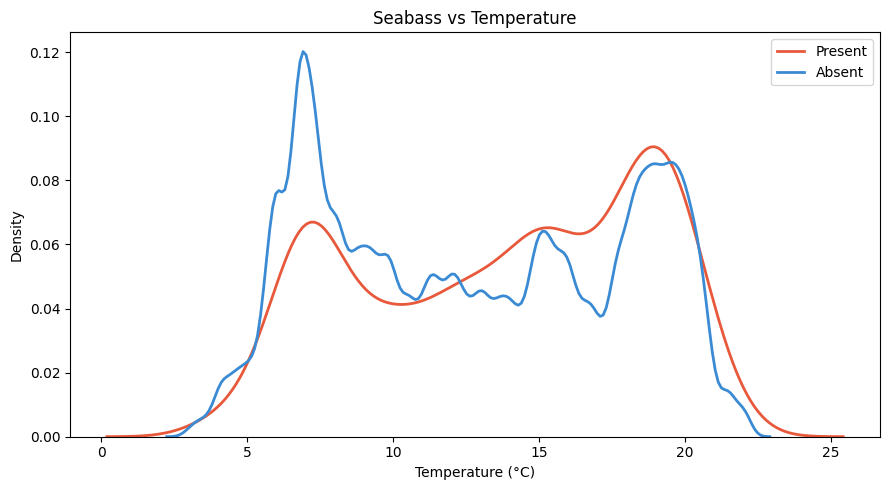

In [51]:
present = df_visual[present_mask]['temperature_mean'].dropna()
absent  = df_visual[absent_mask]['temperature_mean'].dropna()

fig, ax = plt.subplots(figsize=(9, 5))

sns.kdeplot(present, ax=ax, color='#E8593C', linewidth=2, label='Present')
sns.kdeplot(absent,  ax=ax, color='#3B8BD4', linewidth=2, label='Absent')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Density')
ax.set_title('Seabass vs Temperature')
ax.legend()

plt.tight_layout()
plt.show()

In [52]:
df_clean.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat,salinity_mean,temperature_mean
1,52.7000,4.9000,2010-01-01,1.0000,0,0.0000,14.0130,2.9916,0.0000,0.1010,1.3130,0.0000,0.3768,0.0000,agricultural,30.8636,7.1543
10,53.1000,6.2500,2010-01-01,3.0000,0,0.0000,13.3706,3.3326,0.0000,0.2850,1.4334,0.0000,0.2024,0.0004,agricultural,30.8636,7.1543
12,53.0000,4.8500,2010-01-01,4.0000,0,0.0000,0.3190,0.2124,17.8631,0.0000,0.2691,0.0000,0.0013,0.0000,coast,30.8636,7.1543
14,53.0000,6.3500,2010-01-01,1.0000,0,0.0000,8.1099,0.7517,0.0000,2.2248,1.0658,0.1880,0.2144,6.1126,agricultural,30.8636,7.1543
15,52.2500,5.4500,2010-01-01,6.0000,0,0.0000,8.4355,0.1978,0.0000,6.7546,1.3098,0.0023,2.1768,0.1150,agricultural,30.8636,7.1543


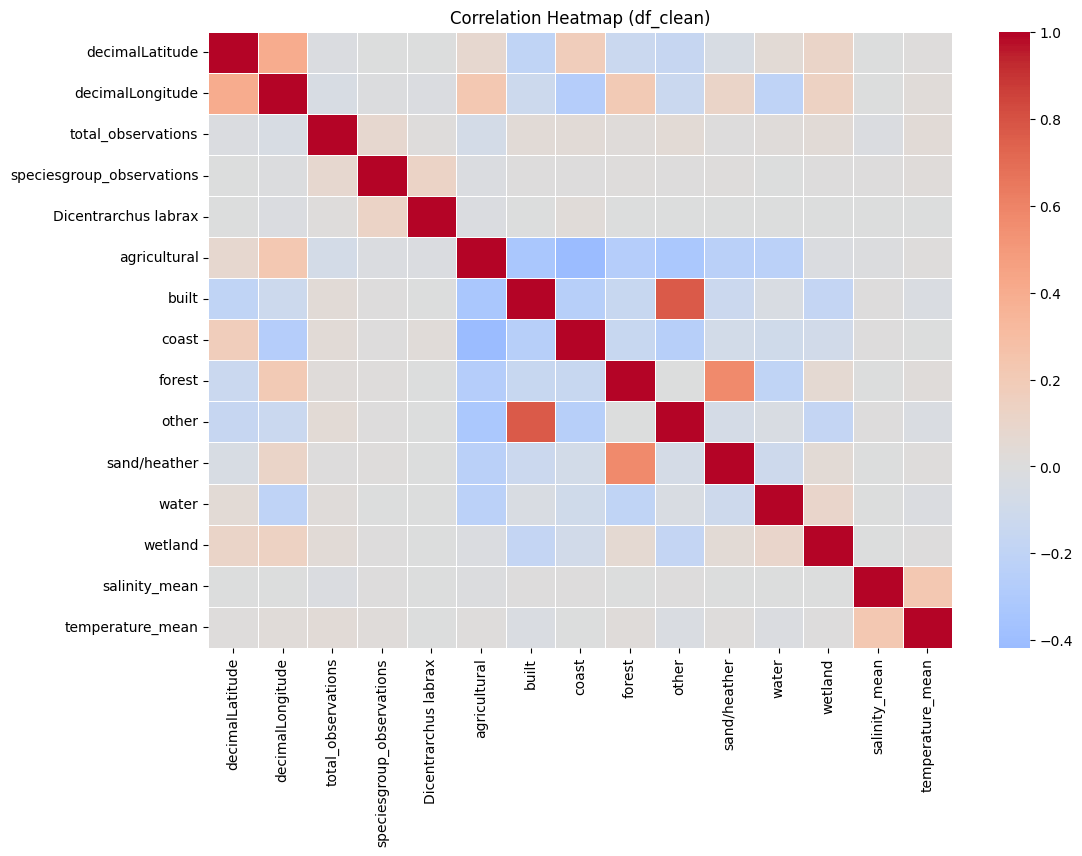

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_num = df_clean.select_dtypes(include=['number'])

corr = df_num.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap (df_clean)")
plt.show()

In [58]:
df_ml = df_clean.copy()
df_ml['presence'] = (df_ml['Dicentrarchus labrax'] > 0).astype(int)

print(f"Class distribution:\n{df_ml['presence'].value_counts()}")
print(f"Positive rate: {df_ml['presence'].mean():.4f}")

df_ml['year'] = df_ml['eventDate'].dt.year
df_ml['month'] = df_ml['eventDate'].dt.month
df_ml['month_sin'] = np.sin(2 * np.pi * df_ml['month'] / 12)
df_ml['month_cos'] = np.cos(2 * np.pi * df_ml['month'] / 12)

features = [
    'decimalLatitude', 'decimalLongitude',
    'total_observations',
    'speciesgroup_observations',
    'year',
    'month_sin', 'month_cos',
    'agricultural', 'built', 'coast', 'forest',
    'other', 'sand/heather', 'water', 'wetland',
    'salinity_mean', 'temperature_mean',
]


X = df_ml[features]
y = df_ml['presence']

Class distribution:
presence
0    6537558
1       2041
Name: count, dtype: int64
Positive rate: 0.0003


In [59]:
train_df = df_ml[df_ml['year'] < 2024]
test_df  = df_ml[df_ml['year'] >= 2024]

X_train = train_df[features]
y_train = train_df['presence']
X_test  = test_df[features]
y_test  = test_df['presence']

print(f"Train: {len(X_train)} rows, {y_train.sum()} positive ({y_train.mean():.4f})")
print(f"Test:  {len(X_test)} rows, {y_test.sum()} positive ({y_test.mean():.4f})")

Train: 5414345 rows, 1592 positive (0.0003)
Test:  1125254 rows, 449 positive (0.0004)


In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, precision_recall_curve

rf = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob):.4f}")

feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\n=== Feature Importance ===")
print(feat_imp)

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1124805
           1       0.02      0.68      0.04       449

    accuracy                           0.99   1125254
   macro avg       0.51      0.83      0.52   1125254
weighted avg       1.00      0.99      0.99   1125254

ROC-AUC: 0.9773
PR-AUC:  0.3243

=== Feature Importance ===
coast                       0.2606
decimalLongitude            0.1912
speciesgroup_observations   0.1793
agricultural                0.0700
forest                      0.0550
total_observations          0.0326
water                       0.0302
temperature_mean            0.0290
sand/heather                0.0252
built                       0.0220
decimalLatitude             0.0214
other                       0.0212
salinity_mean               0.0162
month_sin                   0.0129
wetland                     0.0128
year                        0.0122
month_cos              

In [61]:
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * precision_curve * recall_curve / (precision_curve + recall_curve + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Precision: {precision_curve[best_idx]:.3f}")
print(f"Recall:    {recall_curve[best_idx]:.3f}")

y_pred_tuned = (y_prob >= best_threshold).astype(int)
print("\n=== Tuned Report ===")
print(classification_report(y_test, y_pred_tuned))

Best threshold: 0.9713
Precision: 0.811
Recall:    0.296

=== Tuned Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1124805
           1       0.81      0.30      0.43       449

    accuracy                           1.00   1125254
   macro avg       0.91      0.65      0.72   1125254
weighted avg       1.00      1.00      1.00   1125254



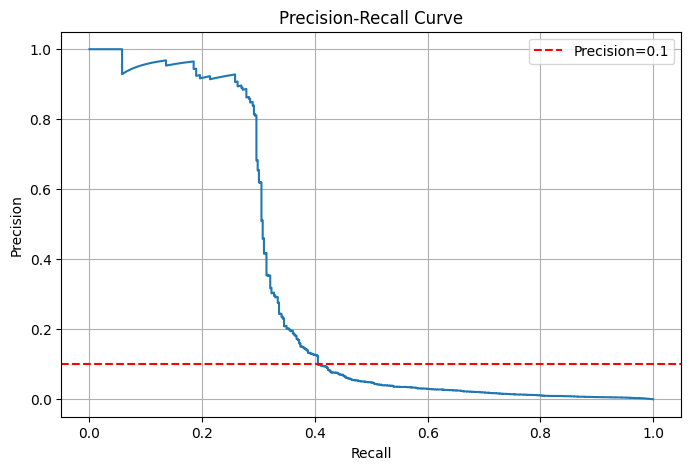

Threshold: 0.9594
Precision: 0.655
Recall:    0.301

=== Report (recall >= 0.3) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1124805
           1       0.66      0.30      0.41       449

    accuracy                           1.00   1125254
   macro avg       0.83      0.65      0.71   1125254
weighted avg       1.00      1.00      1.00   1125254



In [62]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.axhline(y=0.1, color='r', linestyle='--', label='Precision=0.1')
plt.legend()
plt.grid(True)
plt.show()

precision_aligned = precision_curve[:-1]
recall_aligned = recall_curve[:-1]

mask = recall_aligned >= 0.3
best_idx_30 = np.argmax(precision_aligned[mask])
threshold_30 = thresholds[mask][best_idx_30]

print(f"Threshold: {threshold_30:.4f}")
print(f"Precision: {precision_aligned[mask][best_idx_30]:.3f}")
print(f"Recall:    {recall_aligned[mask][best_idx_30]:.3f}")

y_pred_30 = (y_prob >= threshold_30).astype(int)
print("\n=== Report (recall >= 0.3) ===")
print(classification_report(y_test, y_pred_30))

In [63]:
from xgboost import XGBClassifier

scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.1f}")

xgb = XGBClassifier(
    scale_pos_weight=scale, 
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_xgb):.4f}")

scale_pos_weight: 3400.0
ROC-AUC: 0.9756
PR-AUC:  0.3531


In [64]:
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_prob_xgb)

precision_xgb_a = precision_xgb[:-1]
recall_xgb_a = recall_xgb[:-1]

mask = recall_xgb_a >= 0.3
best_idx = np.argmax(precision_xgb_a[mask])
threshold_xgb = thresholds_xgb[mask][best_idx]

print(f"Threshold: {threshold_xgb:.4f}")
print(f"Precision: {precision_xgb_a[mask][best_idx]:.3f}")
print(f"Recall:    {recall_xgb_a[mask][best_idx]:.3f}")

y_pred_xgb = (y_prob_xgb >= threshold_xgb).astype(int)
print("\n=== XGBoost Report (recall >= 0.3) ===")
print(classification_report(y_test, y_pred_xgb))

Threshold: 0.9976
Precision: 0.839
Recall:    0.301

=== XGBoost Report (recall >= 0.3) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1124805
           1       0.84      0.30      0.44       449

    accuracy                           1.00   1125254
   macro avg       0.92      0.65      0.72   1125254
weighted avg       1.00      1.00      1.00   1125254



In [ ]:
# --- STEP 3.2: FULL SCALE TEST DESIGN (ALL DATA) ---
from sklearn.model_selection import train_test_split
import gc

# Clear any old variables to free up RAM
gc.collect()

# We use the X and y we defined in Step 3.1
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Full Training set: {X_train.shape[0]} rows")
print(f"Full Testing set: {X_test.shape[0]} rows")

In [ ]:
# --- STEP 3.3: MEMORY-SAFE BIG RUN ---
from sklearn.ensemble import RandomForestClassifier

# We add 'max_samples' and 'max_depth' so your 16GB RAM doesn't crash
rf_full = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced', 
    n_jobs=-1,           # Using all 14 cores of your i9
    max_samples=0.2,     # RAM SAFETY: Optimization
    max_depth=15,        # RAM SAFETY: Prevents memory overflow
    verbose=1            # Shows you progress
)

rf_full.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

rf_balanced = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1, 
    max_depth=15, 
    verbose=0 
)
rf_balanced.fit(X_train, y_train)

y_pred_test = rf_balanced.predict(X_test)
y_prob_test = rf_balanced.predict_proba(X_test)[:, 1]

print("===== BALANCED DATASET PERFORMANCE =====")
print(classification_report(y_test, y_pred_test))
print("AUC:", roc_auc_score(y_test, y_prob_test))

In [ ]:
# CODE CELL: Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_full = rf_full.predict(X_test)
cm = confusion_matrix(y_test, y_pred_full)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Absent', 'Present'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Predicted vs Actual')
plt.show()

In [ ]:
# CODE CELL: Feature Importance (Which clues mattered most?)
importances = rf_full.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Which Environmental Clues Mattered Most?')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
df_full = df_final.copy()

df_full['target'] = (df_full['Dicentrarchus labrax'] > 0).astype(int)

X_full = df_full.drop(columns=[
    'Dicentrarchus labrax',
    'speciesgroup_observations',
    'total_observations',
    'target',
    'eventDate'
])

y_full = df_full['target']

# 🔥 FIX HERE (关键)
X_full = X_full.reindex(columns=X_train.columns, fill_value=0)

y_pred_full = rf_full.predict(X_full)



from sklearn.metrics import classification_report, roc_auc_score

print("===== REAL WORLD PERFORMANCE =====")
print(classification_report(y_full, y_pred_full))
print("AUC:", roc_auc_score(y_full, rf_full.predict_proba(X_full)[:,1]))

---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

*Describe the Nebula Brokerage pricing problem. Why is their current "gut feeling" approach a risk?.*

**Business objective(s)**

*Justify why a data-driven baseline is needed*

**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

**Success criteria**

*Determine success criteria for this iteration (the benchmark)*

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Include summary statistics and descriptions of data types below. Describe your findings.*

In [ ]:
# CODE CELL: Show basic statistics and information

**Visualizations and patterns**

*Discover patterns in the data by creating visualizations. Create at least a histogram of Galactic_Credits. Describe your observations.*

In [ ]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)

**Data insights and data quality**
* **Insights:** What are the key trends? What does the distribution look like? What does that mean? 
* **Quality issues:** Document missing values, duplicates, outliers, etc.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify steps taken (e.g., imputation, handling outliers, fixing other errors).*

In [ ]:
# CODE CELL: Data cleaning and preprocessing steps

**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [ ]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Describe and justify the creation of your simple benchmark model to predict Galactic_Credits*

In [ ]:
# CODE CELL: Model training and setup code

**Testing and performance**
*Describe how you tested the model and interpret the metrics. Make sure to present the metrics in a clear overview.*

In [ ]:
# CODE CELL: Model evaluation code

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*What is the difference between the metrics? What does this mean? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What did you learn? What are the limitations of this current model?*

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |